# Deep Learning for Aircraft Type Detection and Operator Classification

## Load and show data

### Import and config

In [1]:
import os, random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import sys
sys.path.insert(0, str(Path("../../src")))

from metadata.class_names import CLASS_NAMES
from metadata.operator_mapping import OPERATOR_MAP

DATA_DIR = Path("../../data")
SPLITS = ["train", "val", "test"]

### Build dataframe from label files

In [2]:
records = []

for split in SPLITS:
    label_dir = DATA_DIR / split / "labels"
    image_dir = DATA_DIR / split / "images"

    for label_path in label_dir.glob("*.txt"):
        # Find corresponding image (jpg or png)
        image_path = image_dir / (label_path.stem + ".jpg")
        if not image_path.exists():
            image_path = image_dir / (label_path.stem + ".png")

        # Read label file
        with open(label_path) as f:
            lines = f.read().strip().splitlines()

        # If no annotations, add a record with class_id = -1 (background)
        if not lines:
            records.append({
                "split": split,
                "image_path": str(image_path),
                "label_path": str(label_path),
                "class_id": -1,
                "class_name": "background",
                "operator": "N/A",
                "bbox_x": None, "bbox_y": None,
                "bbox_w": None, "bbox_h": None,
            })
            continue

        for line in lines:
            parts = line.split()
            class_id = int(parts[0])
            class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else "unknown"
            operator = OPERATOR_MAP.get(class_name, "Unknown")
            records.append({
                "split": split,
                "image_path": str(image_path),
                "label_path": str(label_path),
                "class_id": class_id,
                "class_name": class_name,
                "operator": operator,
                "bbox_x": float(parts[1]),
                "bbox_y": float(parts[2]),
                "bbox_w": float(parts[3]),
                "bbox_h": float(parts[4]),
            })

df = pd.DataFrame(records)

### Print dataframe info

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43433 entries, 0 to 43432
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   split       43433 non-null  object 
 1   image_path  43433 non-null  object 
 2   label_path  43433 non-null  object 
 3   class_id    43433 non-null  int64  
 4   class_name  43433 non-null  object 
 5   operator    43433 non-null  object 
 6   bbox_x      40346 non-null  float64
 7   bbox_y      40346 non-null  float64
 8   bbox_w      40346 non-null  float64
 9   bbox_h      40346 non-null  float64
dtypes: float64(4), int64(1), object(5)
memory usage: 3.3+ MB
None


### Print the first 5 rows

In [4]:
df.head(5)

,split,image_path,label_path,class_id,class_name,operator,bbox_x,bbox_y,bbox_w,bbox_h
0,train,../../data/train/images/0000e97ea2d086d6759b19...,../../data/train/labels/0000e97ea2d086d6759b19...,55,Mi28,Non-NATO,0.293750,0.599219,0.028125,0.032813
1,train,../../data/train/images/0000e97ea2d086d6759b19...,../../data/train/labels/0000e97ea2d086d6759b19...,55,Mi28,Non-NATO,0.381250,0.517188,0.031250,0.040625
2,train,../../data/train/images/0000e97ea2d086d6759b19...,../../data/train/labels/0000e97ea2d086d6759b19...,55,Mi28,Non-NATO,0.499219,0.504687,0.026562,0.046875
3,train,../../data/train/images/0000e97ea2d086d6759b19...,../../data/train/labels/0000e97ea2d086d6759b19...,55,Mi28,Non-NATO,0.814844,0.560156,0.032813,0.035937
4,train,../../data/train/images/00010041af654d0b8e1e16...,../../data/train/labels/00010041af654d0b8e1e16...,77,UH60,Both,0.759375,0.308594,0.293750,0.104688


### Print class distribution

In [5]:
class_counts = df["class_name"].value_counts()
print(class_counts)

class_name
background    3087
TB2           1027
F18            999
F16            817
J10            775
              ... 
KF21           285
TB001          272
XB70           271
X32            251
Su47           251
Name: count, Length: 89, dtype: int64


### Display operator distribution

In [6]:
operator_counts = df["operator"].value_counts()
print(operator_counts)

operator
Non-NATO    18863
Both        12721
NATO         8762
N/A          3087
Name: count, dtype: int64


### Visualize random samples with bbox + class + operator

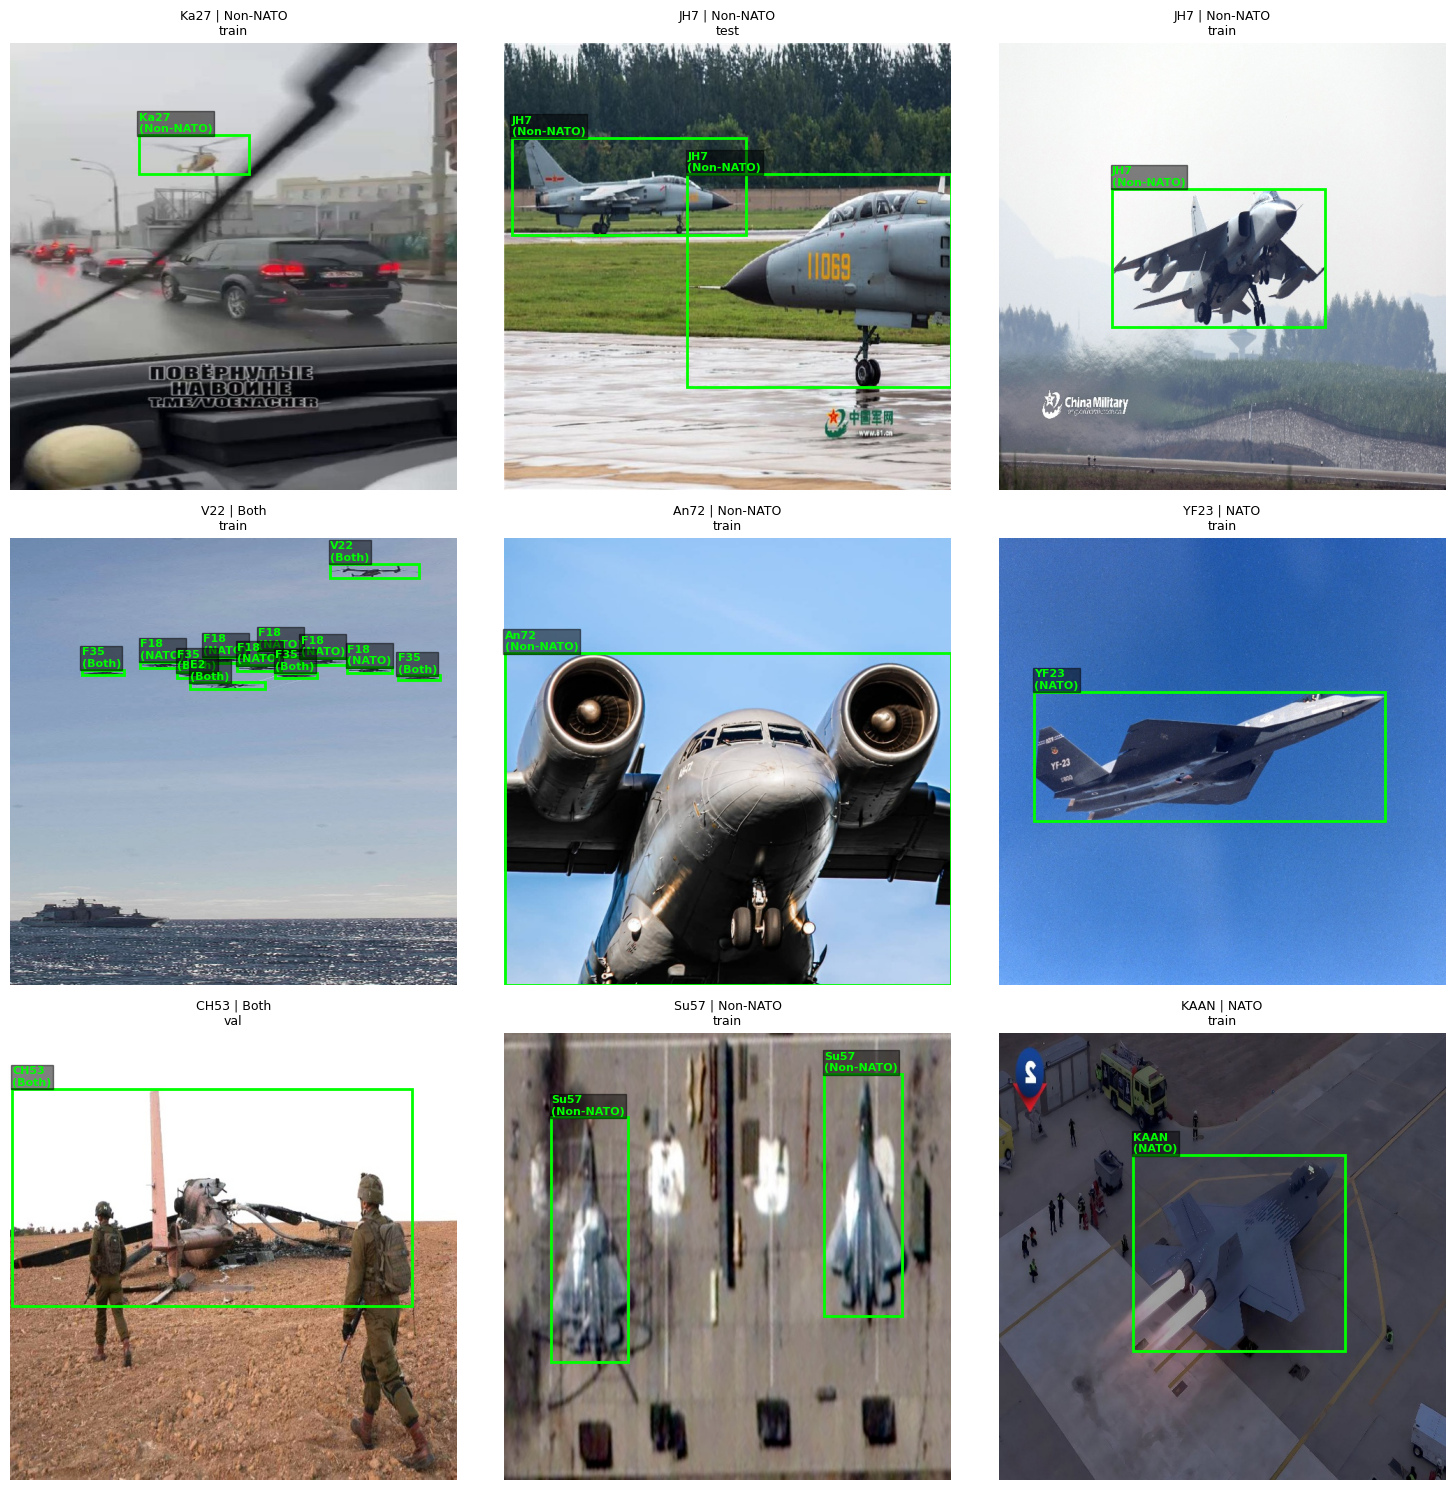

In [7]:
def show_random_samples(df, n=9):
    sample = df[df["class_id"] >= 0].drop_duplicates("image_path").sample(n)
    
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        W, H = img.size

        ax.imshow(img)

        # Draw all annotations for this image
        img_annotations = df[df["image_path"] == row["image_path"]]
        for _, ann in img_annotations.iterrows():
            if ann["class_id"] < 0:
                continue
            cx, cy, bw, bh = ann["bbox_x"], ann["bbox_y"], ann["bbox_w"], ann["bbox_h"]
            x = (cx - bw / 2) * W
            y = (cy - bh / 2) * H
            rect = patches.Rectangle(
                (x, y), bw * W, bh * H,
                linewidth=2, edgecolor="lime", facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x, y - 4, f"{ann['class_name']}\n({ann['operator']})",
                    color="lime", fontsize=8, fontweight="bold",
                    bbox=dict(facecolor="black", alpha=0.5, pad=1))

        ax.set_title(f"{row['class_name']} | {row['operator']}\n{row['split']}", fontsize=9)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_random_samples(df, n=9)

## Model training

### Install Ultralytics

In [8]:
#!pip install ultralytics

### Import libraries

In [9]:
from ultralytics import YOLO
from pathlib import Path
from config import CONFIG

### Load model and train

In [ ]:
model = YOLO(CONFIG["model"])

results = model.train(
    data          = CONFIG["data"],
    imgsz         = CONFIG["imgsz"],
    epochs        = CONFIG["epochs"],
    batch         = CONFIG["batch"],
    optimizer     = CONFIG["optimizer"],
    lr0           = CONFIG["lr0"],
    lrf           = CONFIG["lrf"],
    weight_decay  = CONFIG["weight_decay"],
    device        = CONFIG["device"],
    project       = CONFIG["project"],
    name          = CONFIG["name"],
    exist_ok      = CONFIG["exist_ok"],
    patience      = CONFIG["patience"],
    save_period   = CONFIG["save_period"],
    plots         = CONFIG["plots"],
    mosaic        = CONFIG["mosaic"],
)


### Evaluate model on test set

In [13]:
MODEL_TRAINING_DIR = Path("../../model_training/runs/detect/runs/train/aircraft_yolo11m_v1/weights")

model = YOLO(MODEL_TRAINING_DIR / "best.pt")

metrics = model.val(data='../../dataset.yaml', split='test')

print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

Ultralytics 8.4.22 🚀 Python-3.8.12 torch-2.4.1+cu121 CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
YOLO11m summary (fused): 126 layers, 20,097,880 parameters, 0 gradients, 68.0 GFLOPs
val: Fast image access ✅ (ping: 2.6±0.9 ms, read: 8.3±2.9 MB/s, size: 114.4 KB)
val: Scanning /mnt/c/Users/hugoa/Programmering/Projects/aircraft-detection-and-classification/data/test/labels... 2645 images, 284 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2645/2645 138.1it/s 19.2s<0.1s
val: /mnt/c/Users/hugoa/Programmering/Projects/aircraft-detection-and-classification/data/test/images/aug_TB2_8_c07a9f24486776ec7299f39e94266e8b.jpg: 1 duplicate labels removed
val: New cache created: /mnt/c/Users/hugoa/Programmering/Projects/aircraft-detection-and-classification/data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 166/166 3.5s/it 9:463.3ss
                   all       2645       4148      0.358      0.327      0.305      0.258
     